# Minerva — Full Statistical Analysis

Analysis of a blinded quiz study comparing LLM-generated (Minerva) and RCoA-standard single best answer (SBA) questions, administered to 8 anaesthetists.

**Study design:**
- 30-question quiz: 10 RCoA standard questions + 20 Minerva (LLM-generated) questions
- Participants answered each question and rated clarity, difficulty, and relevancy on 5-point Likert scales
- Participants also guessed the source of each question (Human / LLM / Not Sure)
- Total evaluations: 8 participants × 30 questions = 240

**Analysis sections:**
1. Participant characteristics
2. Correctness analysis
3. Likert scale analysis with TOST equivalence testing
4. Source attribution (blinding assessment)
5. Per-question analysis
6. Subgroup analysis
7. Summary table for publication


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.stats.weightstats import ttost_ind
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

# Publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RCOA_COL    = '#2166ac'   # blue  — RCoA standard questions
MINERVA_COL = '#d6604d'   # red   — LLM-generated questions
PALETTE = {'RCoA': RCOA_COL, 'LLM': MINERVA_COL}
print('Setup complete.')

Setup complete.


---
## Data Loading and Preprocessing

Load responses, define correct answers (from `examples/final.md`), reshape from wide
to long format, and verify computed scores against the CSV `score` column.

In [2]:
data = pd.read_csv('data/responses.csv')

# Question numbers that are RCoA vs Minerva (1-indexed, from examples/final.md)
RCOA_QS    = [2, 4, 8, 9, 12, 16, 19, 22, 26, 28]
MINERVA_QS = [1, 3, 5, 6, 7, 10, 11, 13, 14, 15, 17, 18, 20, 21, 23, 24, 25, 27, 29, 30]

# Correct answers taken from examples/final.md
CORRECT = {
    1:  'Fade in tetanic stimulation',
    2:  'Increase the FGF to 8 L min-1',
    3:  "Drug's half-life",
    4:  'Larger hysteresis loop',
    5:  'It allows oxygenated blood from the umbilical vein to bypass the liver and flow into the inferior vena cava.',
    6:  'It represents the drug being distributed into a peripheral compartment.',
    7:  'The foramen ovale, facilitating blood flow from the right atrium to the left atrium.',
    8:  'Protein synthesis',
    9:  '81.9 mcg mL^-1',
    10: 'Acute tubular necrosis due to ischaemia',
    11: 'Vecuronium has a shorter duration of action',
    12: 'Rocuronium has lower potency',
    13: 'Dynamic airway compression during forced expiration',
    14: 'The concentration of the volatile agent delivered to the patient will be higher than intended.',
    15: 'Potential to cause post-operative nausea and vomiting',
    16: 'Speed of onset faster than nitrous oxide',
    17: 'Presence of arrhythmias such as atrial fibrillation',
    18: "Gay-Lussac's Law",
    19: "Bowman's capsule",
    20: 'Increased membrane capacitance slows conduction velocity.',
    21: 'Ciprofloxacin',
    22: 'Increasing the extracellular concentration of potassium ions',
    23: 'Metabolic interference with bacterial enzymes',
    24: 'Apply positive end-expiratory pressure (PEEP)',
    25: 'Automatic adjustment of the splitting ratio',
    26: 'The fetal circulation is so arranged that blood with a higher oxygen content flows preferentially across the foramen ovale and is ejected via the left ventricle into the carotid arteries',
    27: 'Decreased glomerular filtration rate due to afferent arteriolar vasoconstriction',
    28: 'Mercury is denser than water',
    29: 'Desflurane',
    30: 'Reduction of sodium permeability during depolarisation',
}

print(f'Loaded {len(data)} participants, {len(RCOA_QS)} RCoA questions, {len(MINERVA_QS)} LLM questions.')

Loaded 8 participants, 10 RCoA questions, 20 LLM questions.


In [3]:
# Reshape wide → long, adding correctness flag and question-type label
rows = []
for pid, row in data.iterrows():
    for q in range(1, 31):
        given   = str(row[f'q{q}']).strip()
        correct = CORRECT[q].strip()
        rows.append({
            'participant': pid + 1,
            'experience':  row['experience'],
            'exam':        row['exam'],
            'question':    q,
            'q_type':      'RCoA' if q in RCOA_QS else 'LLM',
            'answer':      given,
            'correct':     given == correct,
            'clarity':     row[f'q{q}_clarity'],
            'difficulty':  row[f'q{q}_difficulty'],
            'relevancy':   row[f'q{q}_relevancy'],
            'attributed':  row[f'q{q}_source'],
        })

df = pd.DataFrame(rows)

# Validate: compare computed per-participant totals against the CSV score column
computed   = df.groupby('participant')['correct'].sum().values
csv_scores = data['score'].str.extract(r'(\d+)').astype(int).squeeze().values

if (computed == csv_scores).all():
    print('Score validation PASSED — all computed scores match CSV values.')
else:
    diffs = [(i+1, int(c), int(s)) for i,(c,s) in enumerate(zip(computed, csv_scores)) if c != s]
    print(f'Score validation WARNING — mismatches on participant(s): {diffs}')
    print('Check CORRECT dict for those participants; proceeding with computed values.')

print(f'Long-format dataframe: {len(df)} rows  |  '
      f"RCoA: {(df['q_type']=='RCoA').sum()}  LLM: {(df['q_type']=='LLM').sum()}")

Score validation PASSED — all computed scores match CSV values.
Long-format dataframe: 240 rows  |  RCoA: 80  LLM: 160


---
## 1. Participant Characteristics

In [4]:
EXP_ORDER  = ['Less than 1 year', 'Between 1 and 2 years',
               'Between 2 and 5 years', 'Over 10 years']
EXAM_ORDER = ['Neither', 'Passed']

participants = data[['experience', 'exam', 'score']].copy()
participants.index = range(1, len(participants) + 1)
participants.index.name = 'Participant'
participants.columns = ['Experience', 'Exam status', 'Score (/ 30)']

print('=== Individual Participant Summary ===\n')
print(participants.to_string())

scores = data['score'].str.extract(r'(\d+)').astype(int).squeeze()
print(f'\nOverall scores — mean: {scores.mean():.1f}  SD: {scores.std():.1f}  '
      f'range: {scores.min()}–{scores.max()}')

print('\n=== Experience Distribution ===')
exp_counts = data['experience'].value_counts().reindex(
    [e for e in EXP_ORDER if e in data['experience'].values])
print(exp_counts.to_string())

print('\n=== Exam Status Distribution ===')
print(data['exam'].value_counts().reindex(
    [e for e in EXAM_ORDER if e in data['exam'].values]).to_string())

=== Individual Participant Summary ===

                        Experience Exam status Score (/ 30)
Participant                                                
1            Between 1 and 2 years      Passed      13 / 30
2            Between 1 and 2 years     Neither      19 / 30
3            Between 1 and 2 years      Passed      27 / 30
4                    Over 10 years      Passed      19 / 30
5                 Less than 1 year     Neither      13 / 30
6            Between 2 and 5 years      Passed      17 / 30
7            Between 1 and 2 years     Neither      19 / 30
8                 Less than 1 year     Neither      14 / 30

Overall scores — mean: 17.6  SD: 4.6  range: 13–27

=== Experience Distribution ===
experience
Less than 1 year         2
Between 1 and 2 years    4
Between 2 and 5 years    1
Over 10 years            1

=== Exam Status Distribution ===
exam
Neither    4
Passed     4


---
## 2. Correctness Analysis

Proportion of correct answers for RCoA versus LLM-generated questions.
Fisher's exact test is used given the small sample.
Wilson score 95% confidence intervals are reported for each proportion.

In [5]:
def wilson_ci(k, n, z=1.96):
    """Wilson score 95% confidence interval for a proportion k/n."""
    p = k / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half   = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (centre - half, centre + half)

# Overall correctness by question type
corr = df.groupby('q_type')['correct'].agg(['sum', 'count'])
corr['pct']           = corr['sum'] / corr['count'] * 100
corr[['ci_lo','ci_hi']] = corr.apply(
    lambda r: wilson_ci(r['sum'], r['count']), axis=1, result_type='expand')
corr[['ci_lo','ci_hi']] *= 100

print('=== Overall Correctness by Question Type ===\n')
for qt, r in corr.iterrows():
    print(f'{qt:5s}: {int(r["sum"]):3d}/{int(r["count"]):3d}  '
          f'({r["pct"]:.1f}%)  '
          f'95% CI [{r["ci_lo"]:.1f}%, {r["ci_hi"]:.1f}%]')

# Fisher's exact test on the 2×2 contingency table
ct = pd.crosstab(df['q_type'], df['correct'])
odds_ratio, p_fisher = fisher_exact(ct)
print(f'\nFisher exact test: OR = {odds_ratio:.2f},  p = {p_fisher:.4f}')

# Per-participant breakdown
print('\n=== Per-Participant Correctness by Question Type (%)')
per_p = (df.groupby(['participant','q_type'])['correct']
           .mean() * 100).unstack('q_type').round(1)
per_p['Delta (RCoA - LLM)'] = (per_p['RCoA'] - per_p['LLM']).round(1)
print(per_p.to_string())

=== Overall Correctness by Question Type ===

LLM  :  90/160  (56.2%)  95% CI [48.5%, 63.7%]
RCoA :  51/ 80  (63.7%)  95% CI [52.8%, 73.4%]

Fisher exact test: OR = 1.37,  p = 0.3303

=== Per-Participant Correctness by Question Type (%)
q_type        LLM   RCoA  Delta (RCoA - LLM)
participant                                 
1            40.0   50.0                10.0
2            60.0   70.0                10.0
3            85.0  100.0                15.0
4            60.0   70.0                10.0
5            45.0   40.0                -5.0
6            55.0   60.0                 5.0
7            60.0   70.0                10.0
8            45.0   50.0                 5.0


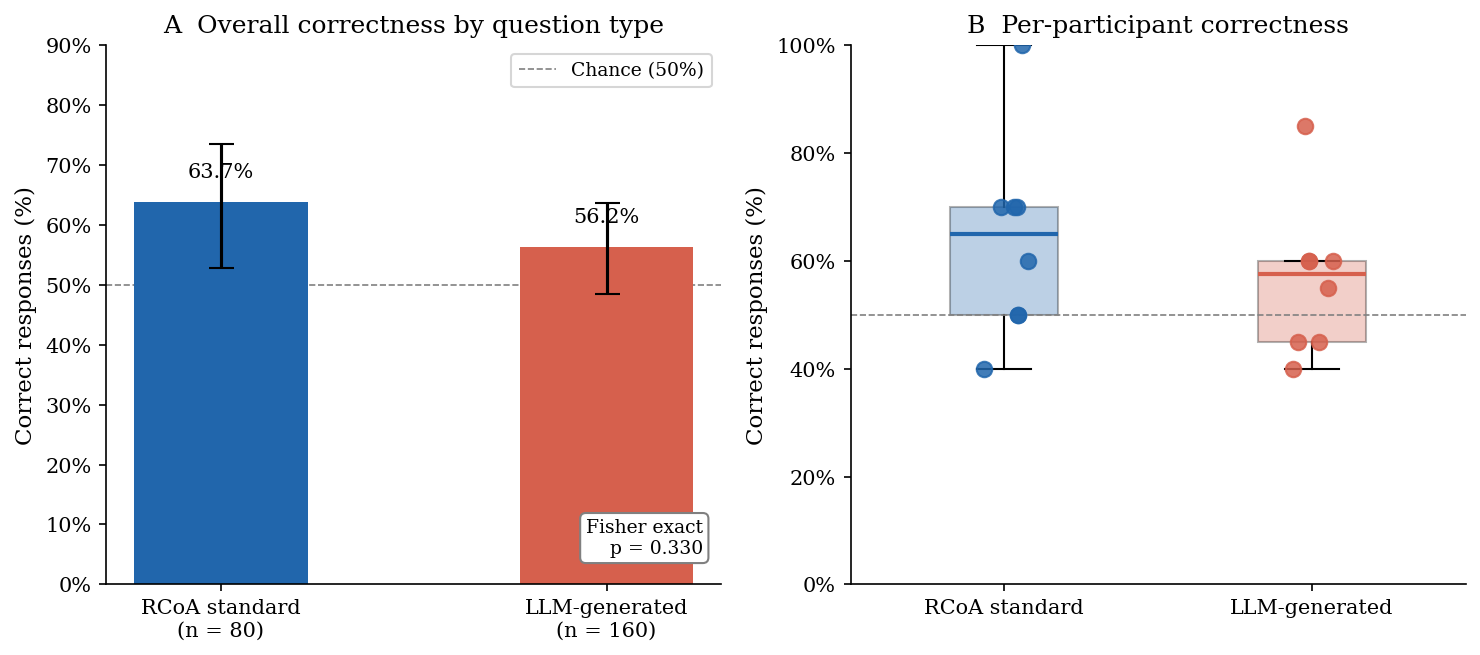

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ── Left: overall proportion correct with 95% CI ──────────────────────────────
ax = axes[0]
qtypes  = ['RCoA', 'LLM']
cols    = [RCOA_COL, MINERVA_COL]
xlabels = ['RCoA standard\n(n = 80)', 'LLM-generated\n(n = 160)']
props   = [corr.loc[qt, 'pct'] for qt in qtypes]
lo_err  = [corr.loc[qt, 'pct'] - corr.loc[qt, 'ci_lo'] for qt in qtypes]
hi_err  = [corr.loc[qt, 'ci_hi'] - corr.loc[qt, 'pct'] for qt in qtypes]

bars = ax.bar(xlabels, props, color=cols, width=0.45,
              yerr=[lo_err, hi_err], capsize=6,
              error_kw={'linewidth': 1.5}, zorder=2)
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, zorder=1, label='Chance (50%)')
ax.set_ylabel('Correct responses (%)')
ax.set_title('A  Overall correctness by question type')
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, p in zip(bars, props):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3.5,
            f'{p:.1f}%', ha='center', va='bottom', fontsize=10)
ax.text(0.97, 0.05, f'Fisher exact\np = {p_fisher:.3f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey'))
ax.legend(fontsize=9)

# ── Right: per-participant scores by question type ────────────────────────────
ax = axes[1]
per_p_long = (df.groupby(['participant','q_type'])['correct']
               .mean() * 100).reset_index()

rng = np.random.default_rng(42)
for i, (qt, col) in enumerate(zip(qtypes, cols)):
    vals = per_p_long[per_p_long['q_type'] == qt]['correct']
    ax.boxplot(vals, positions=[i], widths=0.35,
               patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.3, linewidth=1),
               medianprops=dict(color=col, linewidth=2),
               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
               flierprops=dict(marker=''))
    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(i + jitter, vals, color=col, s=55, zorder=3, alpha=0.85)

ax.set_xticks([0, 1])
ax.set_xticklabels(['RCoA standard', 'LLM-generated'])
ax.set_ylabel('Correct responses (%)')
ax.set_title('B  Per-participant correctness')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8)

fig.tight_layout()
fig.savefig('figures/fig1_correctness.png')
plt.show()

---
## 3. Likert Scale Analysis

Participants rated each question on three 5-point Likert scales: **clarity**,
**difficulty**, and **relevancy**.

Statistical equivalence is tested using the **Two One-Sided Tests (TOST)** procedure
with an equivalence bound of ±0.5 (10% of the 5-point scale range). Equivalence is
declared when both one-sided tests reach p < 0.05, which is equivalent to the 90%
confidence interval on the mean difference lying entirely within (−0.5, +0.5).

In [7]:
DELTA   = 0.5
METRICS = ['clarity', 'difficulty', 'relevancy']

rcoa_df    = df[df['q_type'] == 'RCoA']
minerva_df = df[df['q_type'] == 'LLM']

print('=== Likert Scale Summary and TOST Equivalence Testing ===')
print(f'Equivalence bound: \u00b1{DELTA} Likert points\n')
header = (f'{"Metric":<12}  {"RCoA (mean\u00b1SD)":<18}  {"LLM (mean\u00b1SD)":<18}  '
          f'{"Difference":<12}  {"90% CI":<22}  {"TOST p":<10}  Conclusion')
print(header)
print('-' * len(header))

tost_results = {}
for metric in METRICS:
    g1 = rcoa_df[metric].dropna()
    g2 = minerva_df[metric].dropna()

    m1, sd1 = g1.mean(), g1.std()
    m2, sd2 = g2.mean(), g2.std()
    diff    = m1 - m2

    # TOST from statsmodels; p-value is the max of the two one-sided tests
    p_tost, (t_lo, p_lo, df_lo), (t_hi, p_hi, df_hi) = ttost_ind(g1, g2, -DELTA, DELTA)

    # 90% CI on the difference (t_{0.95} critical value for alpha = 0.05 TOST)
    se     = np.sqrt(g1.var()/len(g1) + g2.var()/len(g2))
    t_crit = stats.t.ppf(0.95, df=df_lo)
    ci_lo  = diff - t_crit * se
    ci_hi  = diff + t_crit * se

    equiv  = 'EQUIVALENT' if p_tost < 0.05 else 'NOT equivalent'
    tost_results[metric] = dict(
        rcoa_mean=m1, rcoa_sd=sd1, llm_mean=m2, llm_sd=sd2,
        diff=diff, ci_lo=ci_lo, ci_hi=ci_hi,
        p_tost=p_tost, equiv=equiv,
    )

    p_str = f'{p_tost:.4f}' if p_tost >= 0.0001 else '<0.0001'
    print(f'{metric.capitalize():<12}  {m1:.2f}\u00b1{sd1:.2f}             '
          f'{m2:.2f}\u00b1{sd2:.2f}             '
          f'{diff:+.3f}        '
          f'[{ci_lo:+.3f}, {ci_hi:+.3f}]    '
          f'{p_str:<10}  {equiv}')

print(f'\nNote: 90% CI used (corresponds to \u03b1 = 0.05 for two one-sided tests).')
print(f'Equivalence declared if 90% CI lies entirely within [\u2212{DELTA}, +{DELTA}].')

=== Likert Scale Summary and TOST Equivalence Testing ===
Equivalence bound: ±0.5 Likert points

Metric        RCoA (mean±SD)      LLM (mean±SD)       Difference    90% CI                  TOST p      Conclusion
------------------------------------------------------------------------------------------------------------------
Clarity       4.26±0.79             4.06±0.88             +0.200        [+0.014, +0.386]    0.0054      EQUIVALENT
Difficulty    3.39±1.10             3.38±0.94             +0.006        [-0.231, +0.243]    0.0002      EQUIVALENT
Relevancy     4.17±0.73             4.14±0.74             +0.031        [-0.134, +0.197]    <0.0001     EQUIVALENT

Note: 90% CI used (corresponds to α = 0.05 for two one-sided tests).
Equivalence declared if 90% CI lies entirely within [−0.5, +0.5].


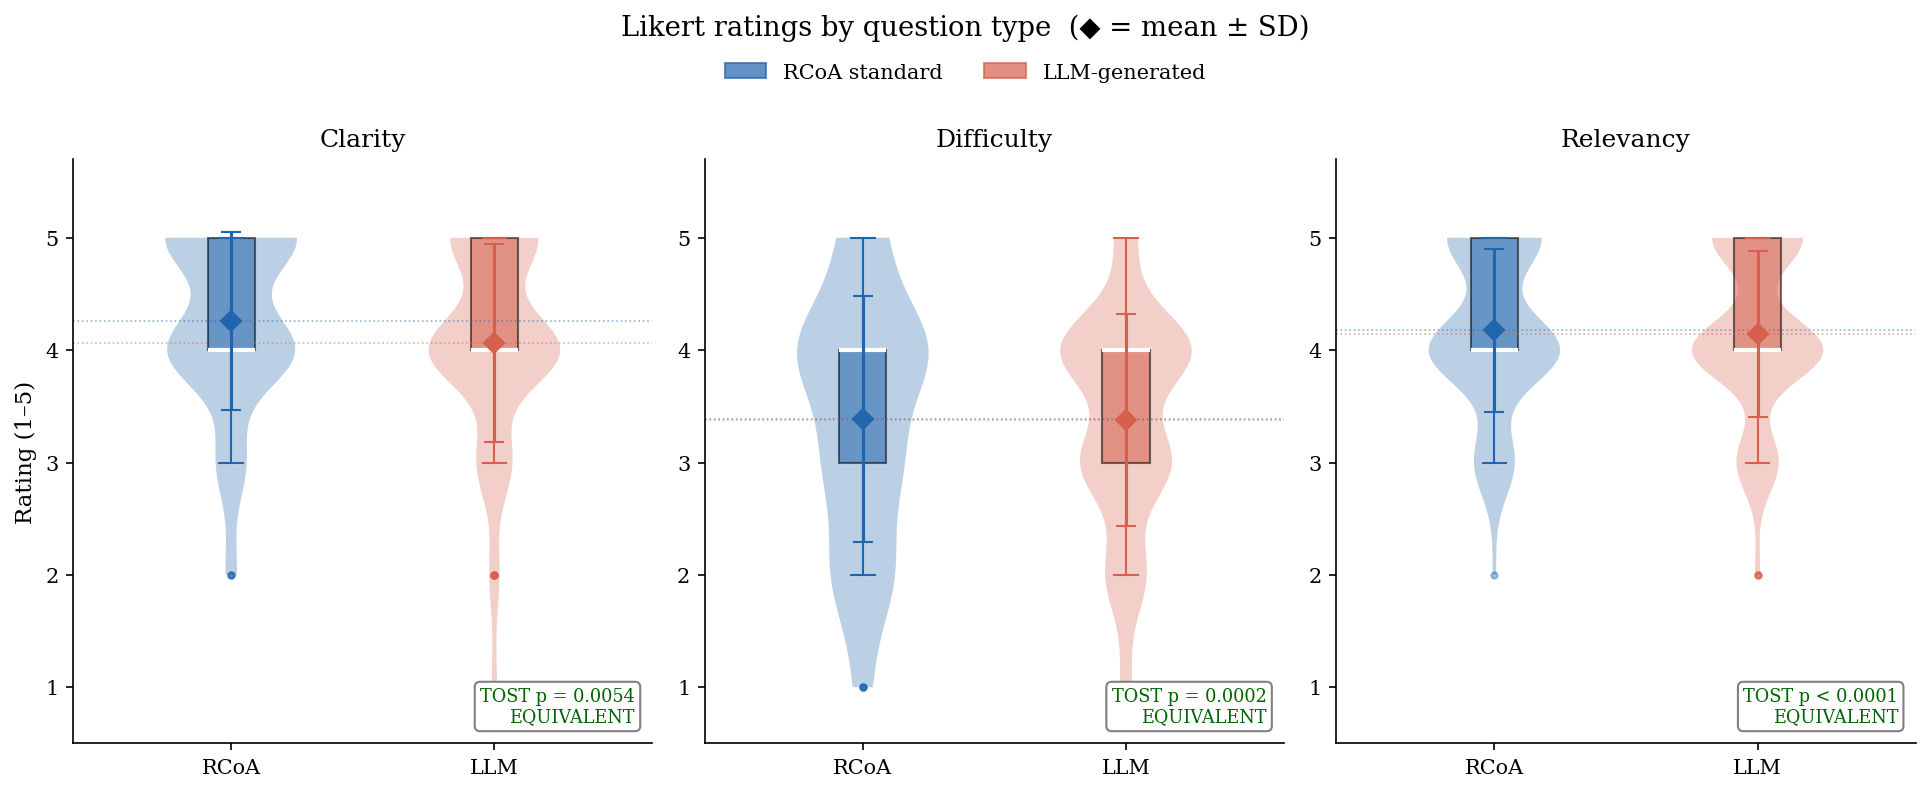

In [8]:
# Violin + box plot for all three Likert metrics
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    r = tost_results[metric]

    # Violin
    parts = ax.violinplot(
        [rcoa_df[metric], minerva_df[metric]],
        positions=[0, 1], showmedians=False, showextrema=False
    )
    for body, col in zip(parts['bodies'], [RCOA_COL, MINERVA_COL]):
        body.set_facecolor(col)
        body.set_alpha(0.3)

    # Overlay box
    for i, (qt, col) in enumerate(zip(['RCoA', 'LLM'], [RCOA_COL, MINERVA_COL])):
        vals = df[df['q_type'] == qt][metric]
        ax.boxplot(vals, positions=[i], widths=0.18,
                   patch_artist=True,
                   boxprops=dict(facecolor=col, alpha=0.55, linewidth=1),
                   medianprops=dict(color='white', linewidth=2),
                   whiskerprops=dict(linewidth=1, color=col),
                   capprops=dict(linewidth=1, color=col),
                   flierprops=dict(marker='o', markerfacecolor=col,
                                   markeredgecolor=col, markersize=3, alpha=0.4))

    # Mean ± SD diamond markers
    for i, (mk, sk, col) in enumerate([
            ('rcoa_mean', 'rcoa_sd', RCOA_COL),
            ('llm_mean',  'llm_sd',  MINERVA_COL)]):
        ax.errorbar(i, r[mk], yerr=r[sk], fmt='D', color=col,
                    markersize=7, capsize=5, linewidth=1.5, zorder=5)

    # Dotted mean reference lines
    ax.axhline(r['rcoa_mean'], color=RCOA_COL,    linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axhline(r['llm_mean'],  color=MINERVA_COL, linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['RCoA', 'LLM'])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(0.5, 5.7)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Rating (1\u20135)' if metric == 'clarity' else '')
    ax.set_title(metric.capitalize())

    p_str  = f'p = {r["p_tost"]:.4f}' if r['p_tost'] >= 0.0001 else 'p < 0.0001'
    colour = 'darkgreen' if r['equiv'] == 'EQUIVALENT' else 'darkred'
    ax.text(0.97, 0.03, f'TOST {p_str}\n{r["equiv"]}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
            color=colour,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey'))

rcoa_p = mpatches.Patch(color=RCOA_COL,    alpha=0.7, label='RCoA standard')
llm_p  = mpatches.Patch(color=MINERVA_COL, alpha=0.7, label='LLM-generated')
fig.legend(handles=[rcoa_p, llm_p], loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.01), frameon=False)
fig.suptitle('Likert ratings by question type  (\u25c6 = mean \u00b1 SD)', y=1.05)
fig.tight_layout()
fig.savefig('figures/fig2_likert_distributions.png')
plt.show()

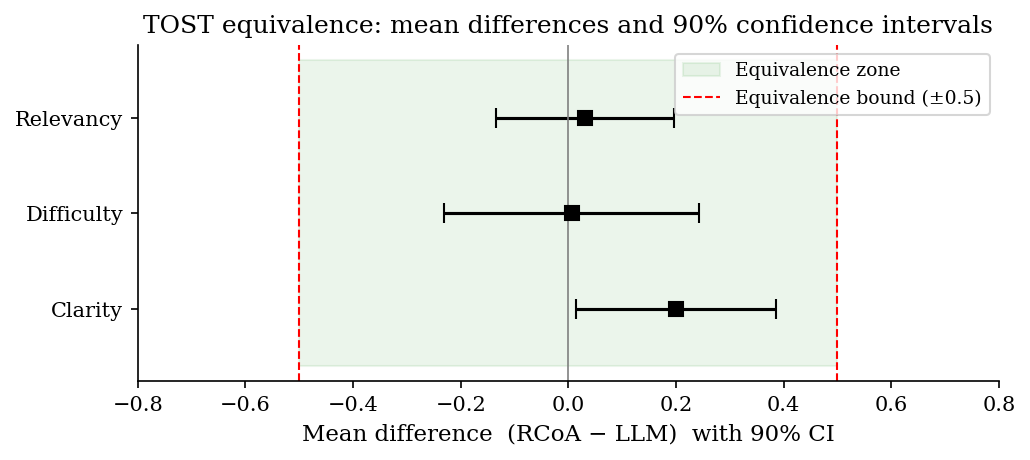

In [9]:
# Forest-plot style: mean difference (RCoA - LLM) with 90% CI and equivalence bounds
fig, ax = plt.subplots(figsize=(7, 3.2))

for i, metric in enumerate(METRICS):
    r = tost_results[metric]
    ax.errorbar(r['diff'], i,
                xerr=[[r['diff'] - r['ci_lo']], [r['ci_hi'] - r['diff']]],
                fmt='s', color='black', markersize=7, capsize=5, linewidth=1.5)

ax.fill_betweenx([-0.6, len(METRICS)-0.4], -DELTA, DELTA,
                  color='green', alpha=0.08, label='Equivalence zone')
ax.axvline(0,      color='grey', linewidth=0.8)
ax.axvline(-DELTA, color='red',  linestyle='--', linewidth=1,
           label=f'Equivalence bound (\u00b1{DELTA})')
ax.axvline( DELTA, color='red',  linestyle='--', linewidth=1)

ax.set_yticks(range(len(METRICS)))
ax.set_yticklabels([m.capitalize() for m in METRICS])
ax.set_xlabel('Mean difference  (RCoA \u2212 LLM)  with 90% CI')
ax.set_title('TOST equivalence: mean differences and 90% confidence intervals')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.8, 0.8)

fig.tight_layout()
fig.savefig('figures/fig3_tost_forest.png')
plt.show()

---
## 4. Source Attribution (Blinding Assessment)

Participants guessed whether each question was human-written or LLM-generated.
This tests whether the questions were indistinguishable in practice — a key measure
of face validity. Correct attribution at chance is 33% (three-category guessing: Human,
Not Sure, LLM) or 50% (binary, ignoring 'Not Sure').

In [10]:
# Attribution counts and proportions by actual source
attr_counts = df.groupby(['q_type', 'attributed']).size().unstack(fill_value=0)
attr_pct    = attr_counts.div(attr_counts.sum(axis=1), axis=0) * 100

print('=== Attribution Counts (actual rows, attributed columns) ===')
print(attr_counts.to_string())
print('\n=== Attribution Proportions (%) ===')
print(attr_pct.round(1).to_string())

# Correct identification rates with 95% Wilson CIs
rcoa_n_correct = int(attr_counts.loc['RCoA', 'Human'])
rcoa_n_total   = int(attr_counts.loc['RCoA'].sum())
llm_n_correct  = int(attr_counts.loc['LLM', 'Large Language Model'])
llm_n_total    = int(attr_counts.loc['LLM'].sum())

print('\n=== Correct Source Identification ===')
for label, k, n in [('RCoA identified as Human', rcoa_n_correct, rcoa_n_total),
                     ('LLM identified as LLM',    llm_n_correct,  llm_n_total)]:
    ci = wilson_ci(k, n)
    print(f'{label}: {k}/{n} = {100*k/n:.1f}%  '
          f'95% CI [{100*ci[0]:.1f}%, {100*ci[1]:.1f}%]')

# Chi-square tests
print('\n=== Chi-square Tests ===')
# Within each type: is attribution non-uniform across the three categories?
for qt in ['RCoA', 'LLM']:
    obs      = attr_counts.loc[qt]
    expected = np.full(len(obs), obs.sum() / len(obs))
    chi2, p  = stats.chisquare(obs, expected)
    print(f'{qt} vs uniform:\t\u03c7\u00b2({len(obs)-1}) = {chi2:.2f},  p = {p:.4f}')

# Between types: does attribution pattern differ between RCoA and LLM questions?
chi2_bt, p_bt, dof_bt, _ = chi2_contingency(attr_counts)
print(f'RCoA vs LLM pattern:\t\u03c7\u00b2({dof_bt}) = {chi2_bt:.2f},  p = {p_bt:.4f}')

=== Attribution Counts (actual rows, attributed columns) ===
attributed  Human  Large Language Model  Not Sure
q_type                                           
LLM            62                    42        56
RCoA           40                    16        24

=== Attribution Proportions (%) ===
attributed  Human  Large Language Model  Not Sure
q_type                                           
LLM          38.8                  26.2      35.0
RCoA         50.0                  20.0      30.0

=== Correct Source Identification ===
RCoA identified as Human: 40/80 = 50.0%  95% CI [39.3%, 60.7%]
LLM identified as LLM: 42/160 = 26.2%  95% CI [20.0%, 33.6%]

=== Chi-square Tests ===
RCoA vs uniform:	χ²(2) = 11.20,  p = 0.0037
LLM vs uniform:	χ²(2) = 3.95,  p = 0.1388
RCoA vs LLM pattern:	χ²(2) = 2.85,  p = 0.2405


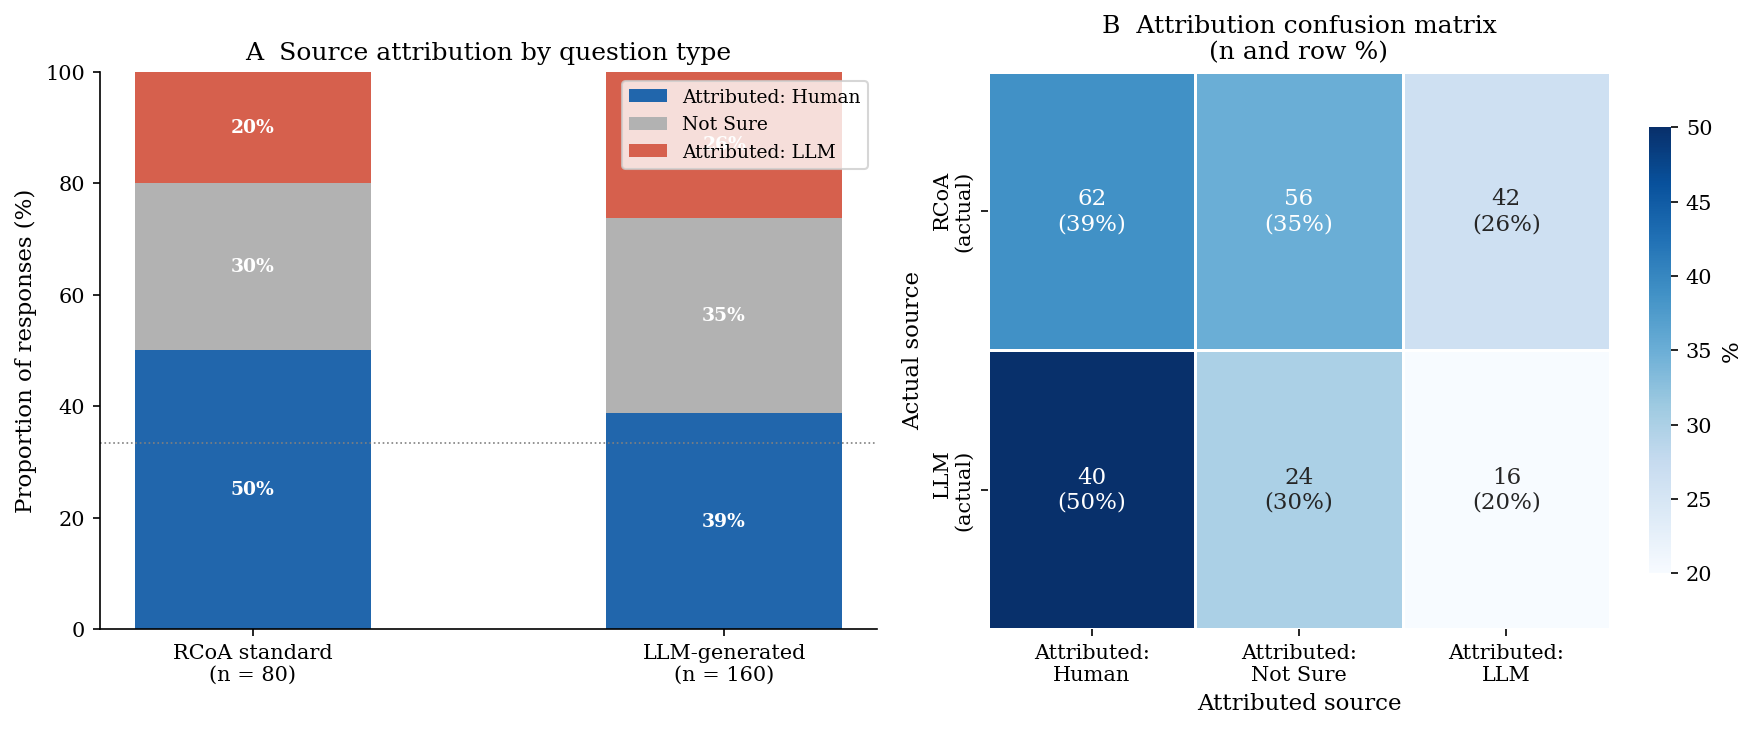

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

CAT_ORDER   = ['Human', 'Not Sure', 'Large Language Model']
CAT_COLS    = ['#2166ac', '#b2b2b2', '#d6604d']
CAT_LABELS  = ['Attributed: Human', 'Not Sure', 'Attributed: LLM']
XTICK_LABS  = ['RCoA standard\n(n = 80)', 'LLM-generated\n(n = 160)']
QTYPES      = ['RCoA', 'LLM']

# Ensure all columns present
for cat in CAT_ORDER:
    if cat not in attr_pct.columns:
        attr_pct[cat] = 0.0
attr_pct_plot = attr_pct[CAT_ORDER]

# ── Left: stacked bar ────────────────────────────────────────────────────────
ax = axes[0]
bottoms = np.zeros(2)
for cat, col, lab in zip(CAT_ORDER, CAT_COLS, CAT_LABELS):
    vals = [attr_pct_plot.loc[qt, cat] for qt in QTYPES]
    ax.bar(XTICK_LABS, vals, bottom=bottoms, color=col, label=lab, width=0.5)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 7:
            ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)

ax.set_ylabel('Proportion of responses (%)')
ax.set_title('A  Source attribution by question type')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=9)
# Chance line (33% for three-category uniform guessing)
ax.axhline(33.3, color='grey', linestyle=':', linewidth=0.8)

# ── Right: confusion matrix heatmap ─────────────────────────────────────────
ax = axes[1]
hm = attr_counts[CAT_ORDER].copy()
hm.index   = ['RCoA\n(actual)', 'LLM\n(actual)']
hm.columns = ['Attributed:\nHuman', 'Attributed:\nNot Sure', 'Attributed:\nLLM']
hm_pct = hm.div(hm.sum(axis=1), axis=0) * 100

# Show both count and percentage in each cell
annot = hm.copy().astype(object)
for r_idx in hm.index:
    for c_idx in hm.columns:
        annot.loc[r_idx, c_idx] = (f"{int(hm.loc[r_idx, c_idx])}\n"
                                    f"({hm_pct.loc[r_idx, c_idx]:.0f}%)")

sns.heatmap(hm_pct, annot=annot, fmt='', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '%', 'shrink': 0.8},
            ax=ax, annot_kws={'size': 11})
ax.set_title('B  Attribution confusion matrix\n(n and row %)')
ax.set_ylabel('Actual source')
ax.set_xlabel('Attributed source')

fig.tight_layout()
fig.savefig('figures/fig4_attribution.png')
plt.show()

---
## 5. Per-question Analysis

Correctness and mean Likert ratings at individual question level, to identify outlier
questions and check whether aggregate results are driven by one or a few items.

In [12]:
q_stats = df.groupby('question').agg(
    q_type      = ('q_type',   'first'),
    n_correct   = ('correct',  'sum'),
    n_total     = ('correct',  'count'),
    pct_correct = ('correct',  lambda x: round(100*x.mean(), 1)),
    clarity     = ('clarity',  'mean'),
    difficulty  = ('difficulty','mean'),
    relevancy   = ('relevancy','mean'),
).round(2)

print('=== Per-question Statistics ===\n')
print(q_stats.to_string())

print('\n=== Extreme Questions ===')
print('Easiest (≥ 87.5% correct):')
print(q_stats[q_stats['pct_correct'] >= 87.5][['q_type','pct_correct']].to_string())
print('Hardest (≤ 25% correct):')
print(q_stats[q_stats['pct_correct'] <= 25][['q_type','pct_correct']].to_string())

=== Per-question Statistics ===

         q_type  n_correct  n_total  pct_correct  clarity  difficulty  relevancy
question                                                                        
1           LLM          3        8         37.5     3.12        3.62       4.00
2          RCoA          7        8         87.5     4.38        2.62       4.38
3           LLM          2        8         25.0     4.25        3.88       4.38
4          RCoA          3        8         37.5     4.12        3.50       4.25
5           LLM          7        8         87.5     4.50        2.75       4.00
6           LLM          6        8         75.0     4.38        2.75       4.25
7           LLM          3        8         37.5     3.88        3.75       4.00
8          RCoA          5        8         62.5     4.75        3.12       4.38
9          RCoA          6        8         75.0     4.38        3.88       4.25
10          LLM          6        8         75.0     4.12        3.38       

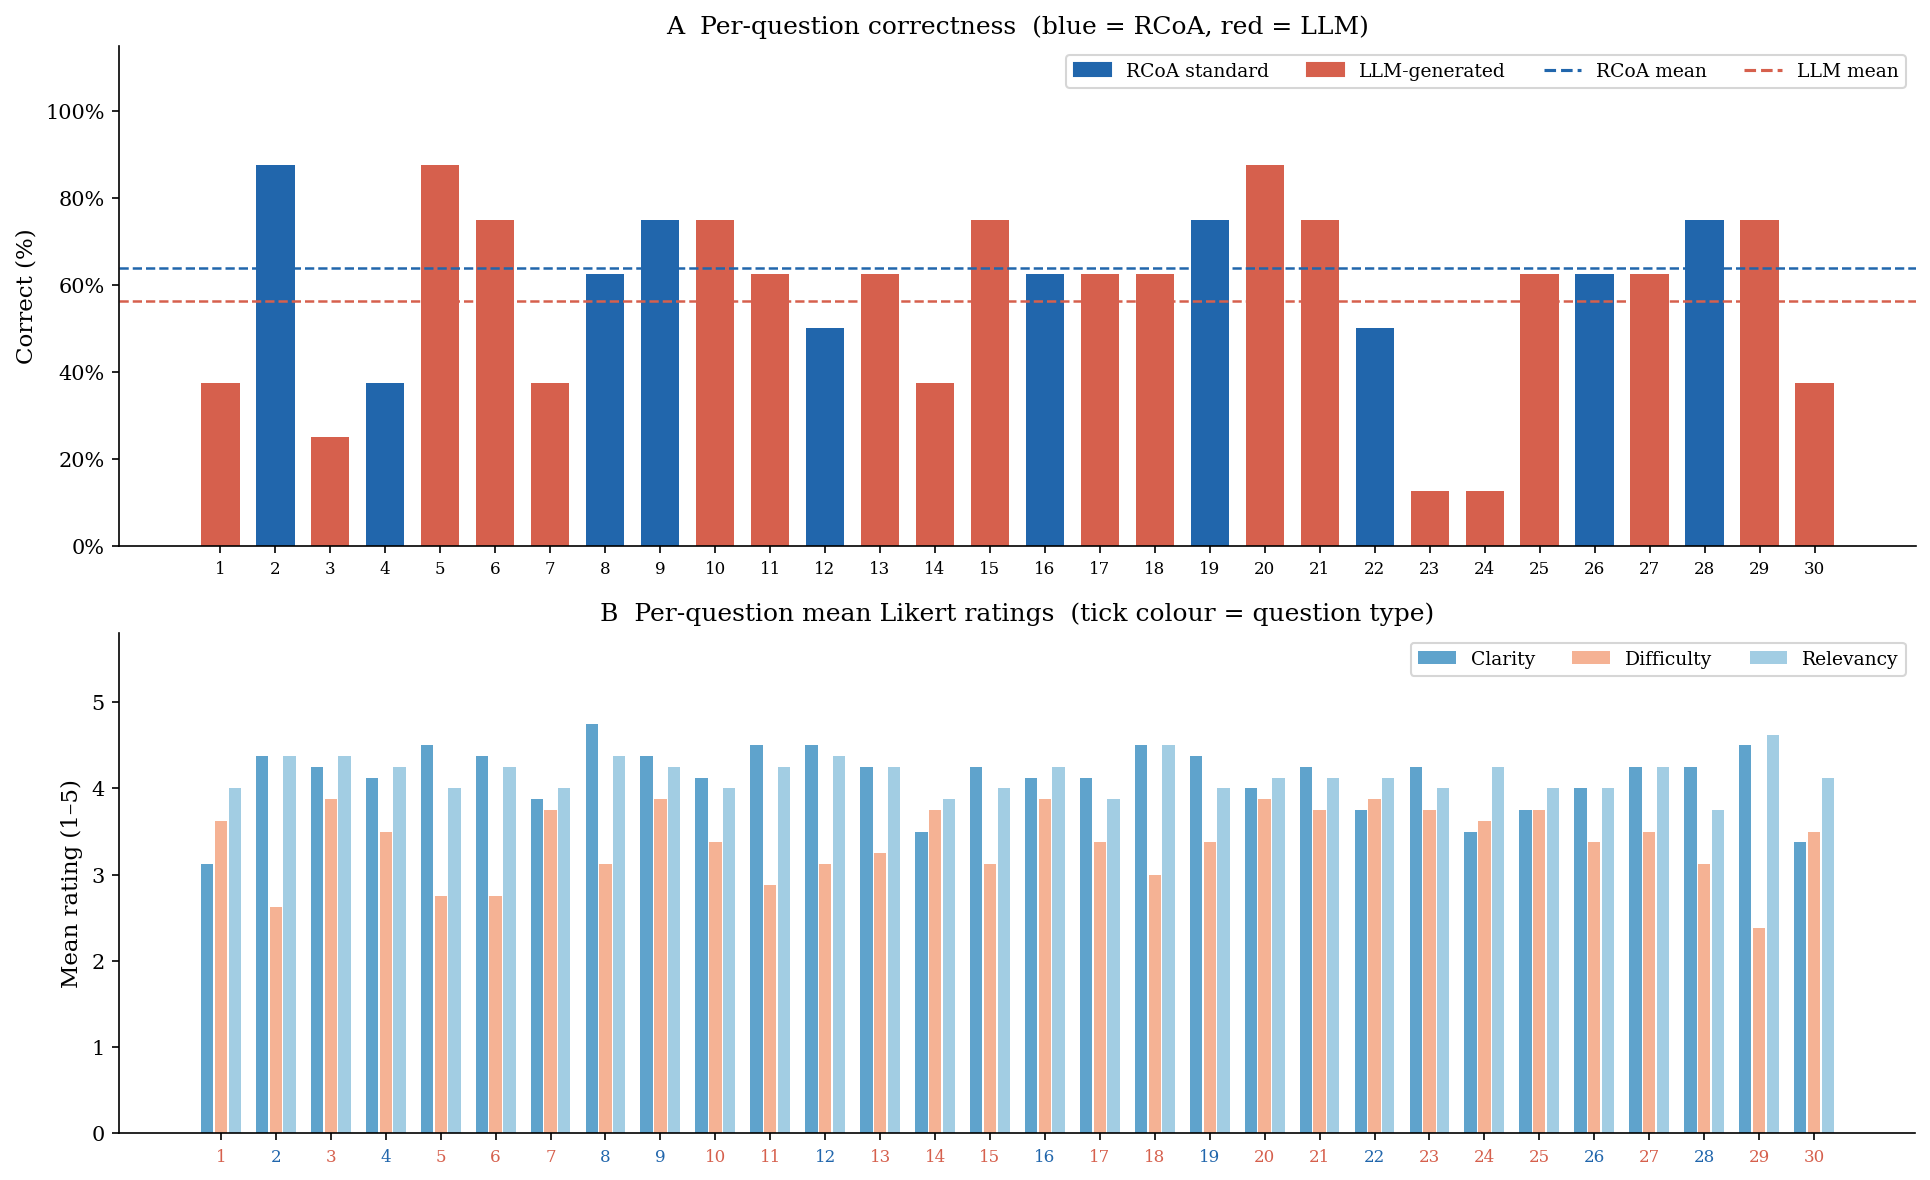

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
q_nums = q_stats.index.tolist()
bar_cols = [RCOA_COL if q_stats.loc[q,'q_type']=='RCoA' else MINERVA_COL for q in q_nums]

# ── Top: per-question correctness ────────────────────────────────────────────
ax = axes[0]
ax.bar(q_nums, q_stats['pct_correct'], color=bar_cols, width=0.7)
ax.axhline(q_stats[q_stats['q_type']=='RCoA']['pct_correct'].mean(),
           color=RCOA_COL,    linestyle='--', linewidth=1.2, label='RCoA mean')
ax.axhline(q_stats[q_stats['q_type']=='LLM']['pct_correct'].mean(),
           color=MINERVA_COL, linestyle='--', linewidth=1.2, label='LLM mean')
ax.set_xticks(q_nums)
ax.set_xticklabels(q_nums, fontsize=8)
ax.set_ylabel('Correct (%)')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('A  Per-question correctness  (blue = RCoA, red = LLM)')
rcoa_p = mpatches.Patch(color=RCOA_COL,    label='RCoA standard')
llm_p  = mpatches.Patch(color=MINERVA_COL, label='LLM-generated')
ax.legend(handles=[rcoa_p, llm_p,
          plt.Line2D([0],[0], color=RCOA_COL,    linestyle='--', label='RCoA mean'),
          plt.Line2D([0],[0], color=MINERVA_COL, linestyle='--', label='LLM mean')],
          fontsize=9, ncol=4)

# ── Bottom: per-question mean Likert ratings ─────────────────────────────────
ax  = axes[1]
w   = 0.25
m_cols = {'Clarity': '#4393c3', 'Difficulty': '#f4a582', 'Relevancy': '#92c5de'}
for (label, mc), offset in zip(m_cols.items(), [-w, 0, w]):
    vals = [q_stats.loc[q, label.lower()] for q in q_nums]
    ax.bar([q + offset for q in q_nums], vals, width=w*0.9,
           color=mc, label=label, alpha=0.85)

ax.set_xticks(q_nums)
ax.set_xticklabels(q_nums, fontsize=8)
# Colour tick labels by question type
for tick, q in zip(ax.get_xticklabels(), q_nums):
    tick.set_color(RCOA_COL if q_stats.loc[q,'q_type']=='RCoA' else MINERVA_COL)
ax.set_ylabel('Mean rating (1\u20135)')
ax.set_ylim(0, 5.8)
ax.set_title('B  Per-question mean Likert ratings  (tick colour = question type)')
ax.legend(fontsize=9, ncol=3)

fig.tight_layout()
fig.savefig('figures/fig5_per_question.png')
plt.show()

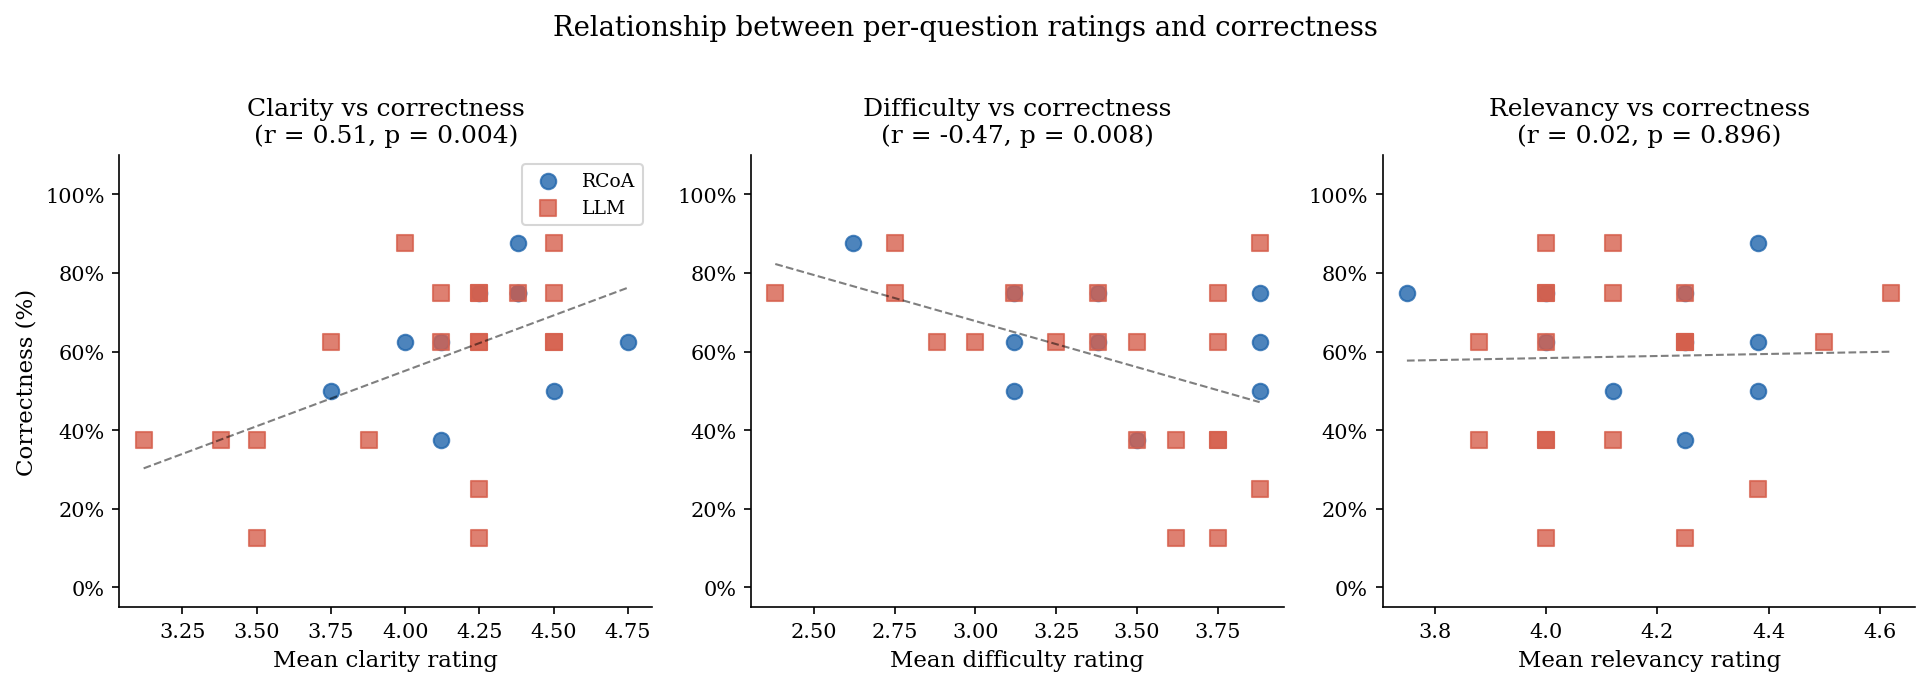

In [14]:
# Scatter: do question ratings correlate with correctness at question level?
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, metric in zip(axes, METRICS):
    for qt, col, marker in [('RCoA', RCOA_COL, 'o'), ('LLM', MINERVA_COL, 's')]:
        sub = q_stats[q_stats['q_type'] == qt]
        ax.scatter(sub[metric], sub['pct_correct'],
                   color=col, marker=marker, s=55, label=qt, alpha=0.8)

    # Regression across all questions
    x = q_stats[metric]
    y = q_stats['pct_correct']
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_line, slope*x_line + intercept,
            color='black', linewidth=1, linestyle='--', alpha=0.5)

    ax.set_xlabel(f'Mean {metric} rating')
    ax.set_ylabel('Correctness (%)' if metric == 'clarity' else '')
    ax.set_title(f'{metric.capitalize()} vs correctness\n'
                 f'(r = {r_val:.2f}, p = {p_val:.3f})')
    ax.set_ylim(-5, 110)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    if metric == 'clarity':
        ax.legend(fontsize=9)

fig.suptitle('Relationship between per-question ratings and correctness', y=1.01)
fig.tight_layout()
fig.savefig('figures/fig6_ratings_vs_correctness.png')
plt.show()

---
## 6. Subgroup Analysis

Descriptive analysis by experience level and exam status. With only 8 participants,
formal hypothesis testing within subgroups is severely underpowered; these results
are exploratory only.

In [15]:
# Per-participant summary for subgroup labelling
part_summary = (df.groupby(['participant', 'experience', 'exam', 'q_type'])
                  .agg(pct_correct=('correct', lambda x: 100*x.mean()),
                       clarity    =('clarity',    'mean'),
                       difficulty =('difficulty', 'mean'),
                       relevancy  =('relevancy',  'mean'))
                  .reset_index())

print('=== Correctness by Exam Status and Question Type (mean \u00b1 SD across participants) ===')
exam_grp = (part_summary.groupby(['exam','q_type'])['pct_correct']
                        .agg(['mean','std','count']).round(1))
print(exam_grp.to_string())

print('\n=== Correctness by Experience Level and Question Type ===')
exp_grp = (part_summary.groupby(['experience','q_type'])['pct_correct']
                       .agg(['mean','std','count']).round(1))
print(exp_grp.to_string())

=== Correctness by Exam Status and Question Type (mean ± SD across participants) ===
                mean   std  count
exam    q_type                   
Neither LLM     52.5   8.7      4
        RCoA    57.5  15.0      4
Passed  LLM     60.0  18.7      4
        RCoA    70.0  21.6      4

=== Correctness by Experience Level and Question Type ===
                              mean   std  count
experience            q_type                   
Between 1 and 2 years LLM     61.2  18.4      4
                      RCoA    72.5  20.6      4
Between 2 and 5 years LLM     55.0   NaN      1
                      RCoA    60.0   NaN      1
Less than 1 year      LLM     45.0   0.0      2
                      RCoA    45.0   7.1      2
Over 10 years         LLM     60.0   NaN      1
                      RCoA    70.0   NaN      1


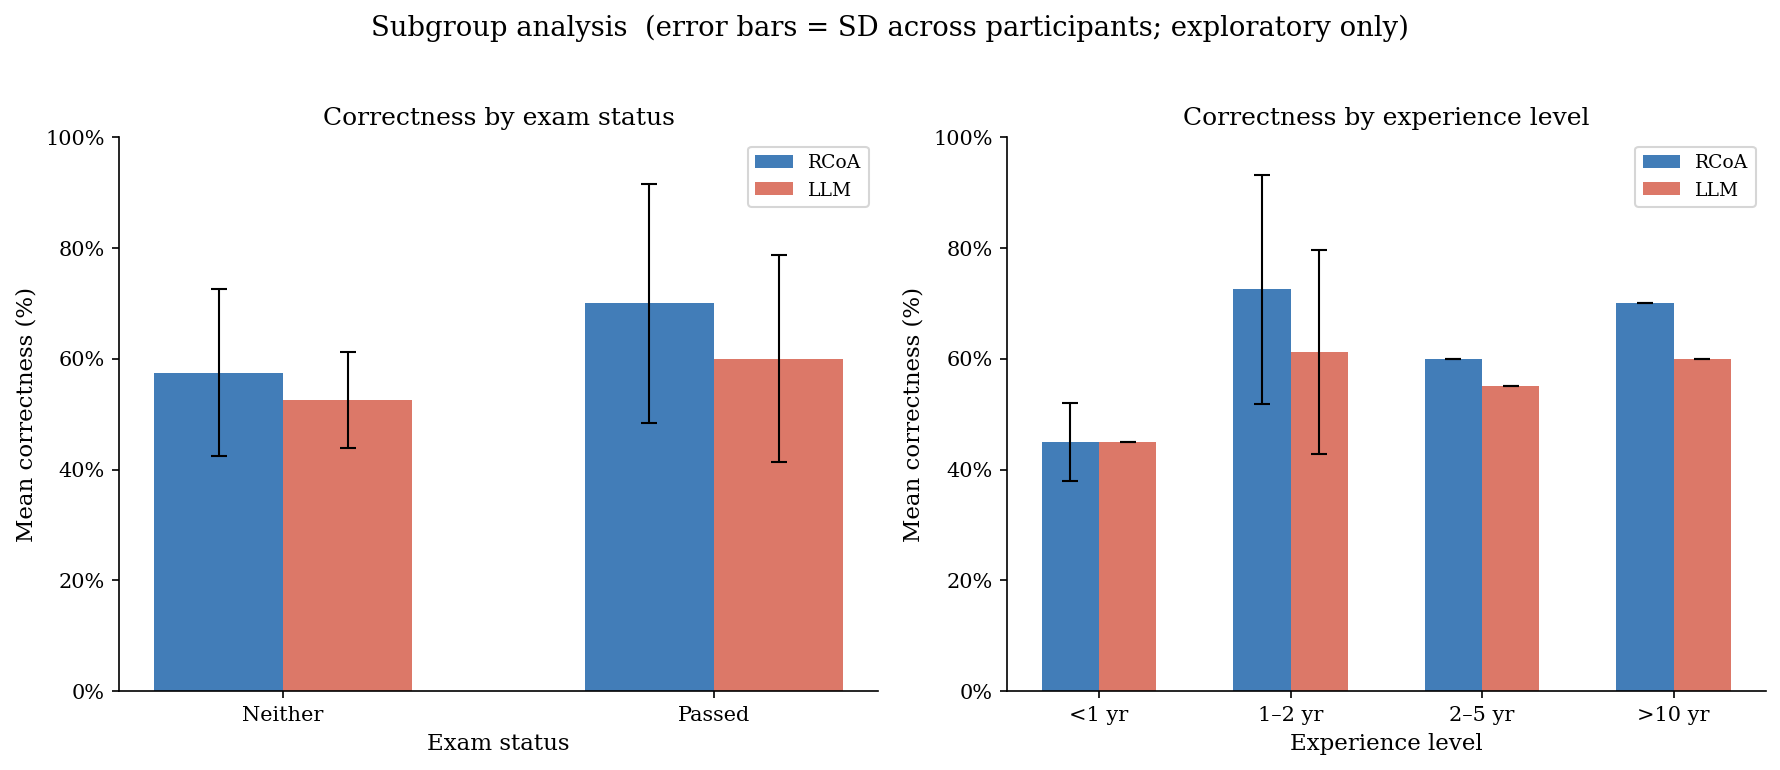

In [16]:
EXP_ABBREV = {
    'Less than 1 year':      '<1 yr',
    'Between 1 and 2 years': '1\u20132 yr',
    'Between 2 and 5 years': '2\u20135 yr',
    'Over 10 years':         '>10 yr',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs = [
    ('exam',       ['Neither', 'Passed'],      'Exam status'),
    ('experience', list(EXP_ABBREV.keys()),    'Experience level'),
]

for ax, (gcol, order, xlabel) in zip(axes, configs):
    sub = part_summary.copy()
    if gcol == 'experience':
        sub[gcol] = sub[gcol].map(EXP_ABBREV)
        present   = [EXP_ABBREV[o] for o in order if o in part_summary[gcol].values]
    else:
        present = [o for o in order if o in sub[gcol].values]

    sub = sub[sub[gcol].isin(present)]
    x   = np.arange(len(present))
    w   = 0.3

    for offset, (qt, col) in zip([-w/2, w/2], [('RCoA', RCOA_COL), ('LLM', MINERVA_COL)]):
        means = [sub[(sub[gcol]==g) & (sub['q_type']==qt)]['pct_correct'].mean() for g in present]
        sds   = [sub[(sub[gcol]==g) & (sub['q_type']==qt)]['pct_correct'].std()  for g in present]
        # Replace NaN std (single observation) with 0
        sds   = [0 if np.isnan(s) else s for s in sds]
        ax.bar(x + offset, means, width=w, color=col, label=qt,
               yerr=sds, capsize=4, error_kw={'linewidth': 1}, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(present)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean correctness (%)')
    ax.set_title(f'Correctness by {xlabel.lower()}')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)

fig.suptitle('Subgroup analysis  (error bars = SD across participants; exploratory only)', y=1.02)
fig.tight_layout()
fig.savefig('figures/fig7_subgroups.png')
plt.show()

---
## 7. Publication Summary Table

Consolidated table of all primary outcome metrics, formatted for inclusion in a manuscript.

In [17]:
table_rows = []

# Correctness
for qt in ['RCoA', 'LLM']:
    sub  = df[df['q_type'] == qt]
    k, n = int(sub['correct'].sum()), len(sub)
    ci   = wilson_ci(k, n)
    table_rows.append({
        'Outcome':    'Correct responses',
        'Group':      qt,
        'Statistic':  f'{100*k/n:.1f}% ({k}/{n})',
        'CI':         f'[{100*ci[0]:.1f}%, {100*ci[1]:.1f}%]  (95%)',
        'Test':       f'Fisher exact  p = {p_fisher:.4f}',
        'Conclusion': 'No significant difference',
    })

# Likert metrics
for metric in METRICS:
    r = tost_results[metric]
    p_str = f'{r["p_tost"]:.4f}' if r['p_tost'] >= 0.0001 else '<0.0001'
    for qt, mk, sk in [('RCoA','rcoa_mean','rcoa_sd'), ('LLM','llm_mean','llm_sd')]:
        table_rows.append({
            'Outcome':    metric.capitalize(),
            'Group':      qt,
            'Statistic':  f'{r[mk]:.2f} \u00b1 {r[sk]:.2f}',
            'CI':         f'Diff 90% CI [{r["ci_lo"]:+.3f}, {r["ci_hi"]:+.3f}]',
            'Test':       f'TOST (\u00b10.5)  p = {p_str}',
            'Conclusion': r['equiv'],
        })

# Source attribution
for qt, k, n in [('RCoA', rcoa_n_correct, rcoa_n_total),
                  ('LLM',  llm_n_correct,  llm_n_total)]:
    ci = wilson_ci(k, n)
    table_rows.append({
        'Outcome':    'Correct attribution',
        'Group':      qt,
        'Statistic':  f'{100*k/n:.1f}% ({k}/{n})',
        'CI':         f'[{100*ci[0]:.1f}%, {100*ci[1]:.1f}%]  (95%)',
        'Test':       '\u2014',
        'Conclusion': '\u2014',
    })

summary_table = pd.DataFrame(table_rows)
print('=== Publication Summary Table ===\n')
print(summary_table.to_string(index=False))

summary_table.to_csv('figures/summary_table.csv', index=False)
print('\nSaved to figures/summary_table.csv')

=== Publication Summary Table ===

            Outcome Group      Statistic                           CI                     Test                Conclusion
  Correct responses  RCoA  63.8% (51/80)        [52.8%, 73.4%]  (95%) Fisher exact  p = 0.3303 No significant difference
  Correct responses   LLM 56.2% (90/160)        [48.5%, 63.7%]  (95%) Fisher exact  p = 0.3303 No significant difference
            Clarity  RCoA    4.26 ± 0.79 Diff 90% CI [+0.014, +0.386]  TOST (±0.5)  p = 0.0054                EQUIVALENT
            Clarity   LLM    4.06 ± 0.88 Diff 90% CI [+0.014, +0.386]  TOST (±0.5)  p = 0.0054                EQUIVALENT
         Difficulty  RCoA    3.39 ± 1.10 Diff 90% CI [-0.231, +0.243]  TOST (±0.5)  p = 0.0002                EQUIVALENT
         Difficulty   LLM    3.38 ± 0.94 Diff 90% CI [-0.231, +0.243]  TOST (±0.5)  p = 0.0002                EQUIVALENT
          Relevancy  RCoA    4.17 ± 0.73 Diff 90% CI [-0.134, +0.197] TOST (±0.5)  p = <0.0001                EQUIVALE

In [18]:
import glob
saved = sorted(glob.glob('figures/*'))
print(f'Output files ({len(saved)}):')
for f in saved:
    print(f'  {f}')

Output files (8):
  figures/fig1_correctness.png
  figures/fig2_likert_distributions.png
  figures/fig3_tost_forest.png
  figures/fig4_attribution.png
  figures/fig5_per_question.png
  figures/fig6_ratings_vs_correctness.png
  figures/fig7_subgroups.png
  figures/summary_table.csv
